In [1]:
from imports import *
from dotenv import load_dotenv
load_dotenv()

C:\Users\yhasm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

### Criando o Estado do Agente

In [2]:
class AgentState(TypedDict):
    texto_original: str
    texto_revisado: str
    feedback_juiz: str
    score: int
    revision_count: int
    messages: Annotated[List[BaseMessage], operator.add]

### Gemini Fake

In [ ]:
class FakeLLM:
    def __init__(self, responses: list):
        self.responses = responses
        self.call_count = 0

    def bind_tools(self, tools): 
        return self

    def invoke(self, messages):
        # Entrega a próxima resposta do roteiro
        if self.call_count < len(self.responses):
            response = self.responses[self.call_count]
            self.call_count += 1
            return response
        else:
            return AIMessage(content="[Fim do Script do Mock]")

In [4]:
@tool
def consultar_guia_estilo(topico: str) -> str:
    """Ferramenta simulada para testes."""
    return f"[MOCK RAG] Regra encontrada para '{topico}': Não use gírias. Seja formal."

# Criamos o nó de ferramenta (que executa a função acima quando chamado)
tools = [consultar_guia_estilo]
tool_node = ToolNode(tools)

In [ ]:
mock_revisor_responses = [
    #o revisor chama a ferramenta (Tool Call)
    AIMessage(
        content="",
        tool_calls=[{"name": "consultar_guia_estilo", "args": {"topico": "tom"}, "id": "call_123"}]
    ),
    #após receber regra, reescreve o texto
    AIMessage(content="Texto Revisado: O produto é excelente, muito obrigado.")
]

#avaliação do Juiz
mock_juiz_responses = [
    AIMessage(content="SCORE: 9\nFEEDBACK: Aprovado. O texto está formal e correto.")
]

llm_revisor = FakeLLM(mock_revisor_responses)
llm_juiz = FakeLLM(mock_juiz_responses)

In [7]:
def revisor_node(state: AgentState):
    print("--- NÓ: REVISOR ---")
    messages = state['messages']
    
    # Se for o início, adiciona o input do usuário na memória
    if not messages:
        messages = [HumanMessage(content=state['texto_original'])]
    
    # O FakeLLM olha o roteiro e decide o que fazer
    revisor_com_tools = llm_revisor.bind_tools(tools) 
    response = revisor_com_tools.invoke(messages)
    
    print(f"   > Ação: {response.tool_calls if response.tool_calls else 'Escreveu texto'}")
    return {"messages": [response]}

def juiz_node(state: AgentState):
    print("--- NÓ: JUIZ ---")
    last_message = state['messages'][-1]
    texto_candidato = last_message.content
    
    # O FakeLLM Juiz dá a nota baseada no roteiro
    avaliacao = llm_juiz.invoke("prompt_ignorado_no_mock")
    conteudo = avaliacao.content
    
    # Extrai o número da nota usando Regex
    import re
    score_match = re.search(r"SCORE: (\d+)", conteudo)
    score = int(score_match.group(1)) if score_match else 0
    
    print(f"   > Decisão: Nota {score}")
    
    return {
        "texto_revisado": texto_candidato,
        "score": score,
        "revision_count": state.get("revision_count", 0) + 1
    }

In [8]:
def deve_continuar(state: AgentState):
    messages = state['messages']
    last_message = messages[-1]
    
    # Se o LLM mandou chamar uma tool, vá para o nó 'tools'
    if last_message.tool_calls:
        return "tools"
    
    # Se não chamou tool, vai para o Juiz avaliar
    return "juiz"

def rota_pos_juiz(state: AgentState):
    # Se nota >= 8, acabou. Senão, volta para o Revisor.
    if state['score'] >= 8:
        return END
    return "revisor"

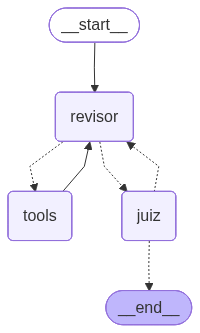

In [9]:
# 1. Criação do Grafo
workflow = StateGraph(AgentState)

# 2. Adição dos Nós
workflow.add_node("revisor", revisor_node)
workflow.add_node("tools", tool_node)
workflow.add_node("juiz", juiz_node)

# 3. Definição das Arestas (Fluxo)
workflow.set_entry_point("revisor")

workflow.add_conditional_edges(
    "revisor", 
    deve_continuar, 
    {"tools": "tools", "juiz": "juiz"}
)

workflow.add_edge("tools", "revisor") # Tools sempre volta pro Revisor

workflow.add_conditional_edges(
    "juiz", 
    rota_pos_juiz, 
    {END: END, "revisor": "revisor"}
)

app = workflow.compile()

# Mapa do fluxo do Agente
display(Image(app.get_graph().draw_mermaid_png()))


In [ ]:
print(">>> INICIANDO EXECUÇÃO SIMULADA <<<")

# esse input serve de gatilho
inputs = {
    "texto_original": "Esse texto tá top, valeu!", 
    "messages": []
}

# Executa o grafo passo a passo
for output in app.stream(inputs):
    # O loop serve apenas para o grafo andar, os prints já estão dentro dos nós
    pass

print("\n>>> PROCESSO CONCLUÍDO <<<")

>>> INICIANDO EXECUÇÃO SIMULADA <<<
--- NÓ: REVISOR ---
   > Ação: [{'name': 'consultar_guia_estilo', 'args': {'topico': 'tom'}, 'id': 'call_123', 'type': 'tool_call'}]
--- NÓ: REVISOR ---
   > Ação: Escreveu texto
--- NÓ: JUIZ ---
   > Decisão: Nota 9

>>> PROCESSO CONCLUÍDO <<<
